In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
#data_path = '/content/drive/MyDrive/cleaned_spy_options.csv'
!pip install tensorflow
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


2025-09-26 18:06:29.619860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

data = pd.read_csv('cleaned_spy_options.csv')

print(f"Data shape: {data.shape}")
print("\nFirst 5 rows:")
print(data.head())

print("\nData types:")
print(data.dtypes)
print("\nMissing values:")
print(data.isna().sum())

Data shape: (5217236, 6)

First 5 rows:
         date      exdate  strike_price cp_flag  underlying_price  \
0  2017-08-31  2017-09-11        2075.0       P           2471.65   
1  2017-08-31  2017-09-11        2100.0       P           2471.65   
2  2017-08-31  2017-09-11        2130.0       P           2471.65   
3  2017-08-31  2017-09-11        2220.0       P           2471.65   
4  2017-08-31  2017-09-11        2235.0       P           2471.65   

   impl_volatility  
0         0.334710  
1         0.333985  
2         0.307310  
3         0.252611  
4         0.243809  

Data types:
date                 object
exdate               object
strike_price        float64
cp_flag              object
underlying_price    float64
impl_volatility     float64
dtype: object

Missing values:
date                0
exdate              0
strike_price        0
cp_flag             0
underlying_price    0
impl_volatility     0
dtype: int64


In [3]:

data['date'] = pd.to_datetime(data['date'])
data['exdate'] = pd.to_datetime(data['exdate'])
data['time_to_expiry'] = (data['exdate'] - data['date']).dt.days
data['strike_price_normalized'] = data['strike_price']
data['moneyness'] = data['strike_price_normalized'] / data['underlying_price']
data = data.dropna(subset=['impl_volatility'])
print(f"Data shape after removing missing values: {data.shape}")

duplicate_count = data.duplicated(subset=['date', 'exdate', 'strike_price', 'cp_flag']).sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    data = data.drop_duplicates(subset=['date', 'exdate', 'strike_price', 'cp_flag'])
    print(f"Data shape after removing duplicates: {data.shape}")

data = data.sort_values(by=['date', 'exdate', 'strike_price', 'cp_flag'])

unique_dates = data['date'].unique()
print(f"Number of unique trading dates: {len(unique_dates)}")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")

Data shape after removing missing values: (5217236, 9)
Number of duplicate rows: 0
Number of unique trading dates: 1510
Date range: 2017-08-31 00:00:00 to 2023-08-31 00:00:00


In [4]:
def get_expiry_bucket(days):
    if days <= 7:
        return 7
    elif days <= 30:
        return 30
    elif days <= 60:
        return 60
    elif days <= 90:
        return 90
    elif days <= 180:
        return 180
    else:
        return 365

data['expiry_bucket'] = data['time_to_expiry'].apply(get_expiry_bucket)

def get_moneyness_bucket(moneyness):
    buckets = np.arange(0.7, 1.35, 0.05)
    return buckets[np.abs(buckets - moneyness).argmin()]

data['moneyness_bucket'] = data['moneyness'].apply(get_moneyness_bucket)

calls = data[data['cp_flag'] == 'C']
puts = data[data['cp_flag'] == 'P']

print("\nDistribution of options by expiry bucket:")
print(data['expiry_bucket'].value_counts().sort_index())

print("\nDistribution of options by moneyness bucket:")
print(data['moneyness_bucket'].value_counts().sort_index())


def check_surface_completeness(date, min_expiry=3, min_moneyness=7):
    day_data = calls[calls['date'] == date]
    unique_expiry = day_data['expiry_bucket'].nunique()
    unique_moneyness = day_data['moneyness_bucket'].nunique()
    return unique_expiry >= min_expiry and unique_moneyness >= min_moneyness

complete_surfaces = [date for date in unique_dates if check_surface_completeness(date)]
print(f"\nDates with complete volatility surfaces: {len(complete_surfaces)} out of {len(unique_dates)}")


Distribution of options by expiry bucket:
30     2093356
60     1326143
90      555123
180     803353
365     439261
Name: expiry_bucket, dtype: int64

Distribution of options by moneyness bucket:
0.70     389698
0.75     158023
0.80     226578
0.85     338491
0.90     553708
0.95     929611
1.00    1419050
1.05     701778
1.10     265014
1.15     110449
1.20      52675
1.25      28095
1.30      16322
1.35      27744
Name: moneyness_bucket, dtype: int64

Dates with complete volatility surfaces: 1510 out of 1510


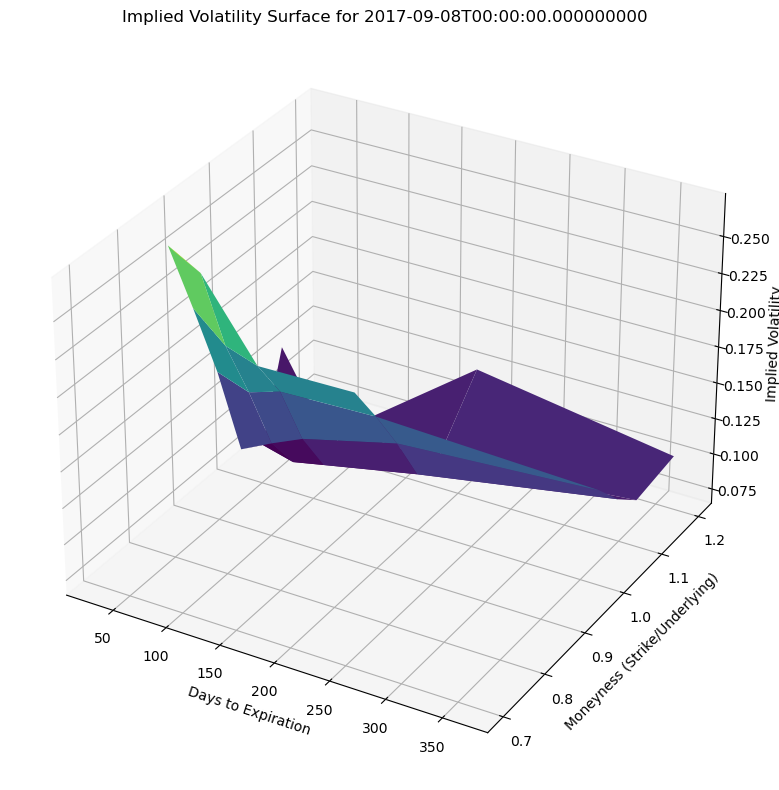

In [5]:
def plot_vol_surface(date_str):
    date = pd.to_datetime(date_str)
    day_data = calls[calls['date'] == date]

    if len(day_data) == 0:
        print(f"No call options data for {date_str}")
        return

    pivot = day_data.pivot_table(
        values='impl_volatility',
        index='moneyness_bucket',
        columns='expiry_bucket',
        aggfunc='mean'
    )

    # Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    x, y = np.meshgrid(pivot.columns, pivot.index)
    ax.plot_surface(x, y, pivot.values, cmap='viridis')

    ax.set_xlabel('Days to Expiration')
    ax.set_ylabel('Moneyness (Strike/Underlying)')
    ax.set_zlabel('Implied Volatility')
    ax.set_title(f'Implied Volatility Surface for {date_str}')

    plt.tight_layout()
    plt.show()

if len(complete_surfaces) > 0:
    sample_date = complete_surfaces[5]
    plot_vol_surface(sample_date)

In [6]:
# Function to create a standardized volatility surface
def create_vol_surface(date, call_data, moneyness_levels, expiry_buckets):

    day_data = call_data[call_data['date'] == date]
    
    surface = np.zeros((len(moneyness_levels), len(expiry_buckets)))
    surface.fill(np.nan)

    for i, m in enumerate(moneyness_levels):
        for j, e in enumerate(expiry_buckets):
            subset = day_data[(day_data['moneyness_bucket'] == m) &
                              (day_data['expiry_bucket'] == e)]
            if not subset.empty:
                surface[i, j] = subset['impl_volatility'].mean()

    from scipy import interpolate

    for j in range(surface.shape[1]):
        col = surface[:, j]
        mask = ~np.isnan(col)
        if np.sum(mask) > 1:
            indices = np.arange(surface.shape[0])
            interp_func = interpolate.interp1d(
                indices[mask], col[mask],
                bounds_error=False, fill_value="extrapolate"
            )
            surface[:, j] = interp_func(indices)

    for i in range(surface.shape[0]):
        row = surface[i, :]
        mask = ~np.isnan(row)
        if np.sum(mask) > 1:
            indices = np.arange(surface.shape[1])
            interp_func = interpolate.interp1d(
                indices[mask], row[mask],
                bounds_error=False, fill_value="extrapolate"
            )
            surface[i, :] = interp_func(indices)

    global_mean = np.nanmean(surface)
    surface[np.isnan(surface)] = global_mean

    return surface

standard_moneyness = sorted(data['moneyness_bucket'].unique())
standard_expiry = sorted(data['expiry_bucket'].unique())

print(f"Standard moneyness levels: {standard_moneyness}")
print(f"Standard expiry buckets: {standard_expiry}")

filtered_dates = complete_surfaces

vol_surfaces = {}
for date in filtered_dates:
    vol_surfaces[date] = create_vol_surface(
        date, calls, standard_moneyness, standard_expiry
    )

print(f"Created {len(vol_surfaces)} volatility surfaces")

Standard moneyness levels: [0.7, 0.75, 0.8, 0.8500000000000001, 0.9000000000000001, 0.9500000000000002, 1.0000000000000002, 1.0500000000000003, 1.1000000000000003, 1.1500000000000004, 1.2000000000000004, 1.2500000000000004, 1.3000000000000005, 1.3500000000000005]
Standard expiry buckets: [30, 60, 90, 180, 365]
Created 1510 volatility surfaces


In [7]:
# Create sequences for LSTM
def create_sequences(surfaces, dates, lookback=20):
    """
    Create sequences of volatility surfaces for LSTM
    X: sequence of volatility surfaces
    y: next day's volatility surface (or chosen target)
    """
    X, y = [], []
    dates = sorted(dates)

    for i in range(lookback, len(dates)):

        seq = []
        for j in range(i - lookback, i):
            seq.append(surfaces[dates[j]])


        target = surfaces[dates[i]]

        X.append(np.array(seq))
        y.append(target)

    return np.array(X), np.array(y)

date_list = sorted(filtered_dates)

# Create sequences with 20-day lookback
lookback = 20
X, y = create_sequences(vol_surfaces, date_list, lookback)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1490, 20, 14, 5)
y shape: (1490, 14, 5)


In [8]:
# Split data chronologically
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Reshape for LSTM input
n_samples, time_steps, n_moneyness, n_expiry = X_train.shape
X_train_reshaped = X_train.reshape(n_samples, time_steps, n_moneyness * n_expiry)
X_val_reshaped = X_val.reshape(X_val.shape[0], time_steps, n_moneyness * n_expiry)
X_test_reshaped = X_test.reshape(X_test.shape[0], time_steps, n_moneyness * n_expiry)

# Similarly reshape targets
y_train_reshaped = y_train.reshape(y_train.shape[0], n_moneyness * n_expiry)
y_val_reshaped = y_val.reshape(y_val.shape[0], n_moneyness * n_expiry)
y_test_reshaped = y_test.reshape(y_test.shape[0], n_moneyness * n_expiry)

Training set: 1043 samples
Validation set: 223 samples
Test set: 224 samples


/Users/misconnor/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │       101,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 96)         │        86,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 96)         │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 70)             │         4,550 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,206 (918.77 KB)

 Trainable params: 234,630 (916.52 KB)

...

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0119 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 23/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - loss: 0.0104 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 24/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0094 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 25/50
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0083

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0083 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 26/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0078

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0077 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 27/50
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0076

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0072 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 28/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0067 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 29/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0062 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 30/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0059 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 31/50
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0052

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0056 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 32/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0054 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 33/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0053 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 34/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0050 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 35/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0050 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 36/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0048 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 37/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0048 - val_loss: 0.0106 - learning_rate: 5.0000e-04
Epoch 38/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0048 - val_loss: 0.0104 - learning_rate: 5.0000e-04
Epoch 39/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0048 - val_loss: 0.0106 - learning_rate: 5.0000e-04
Epoch 40

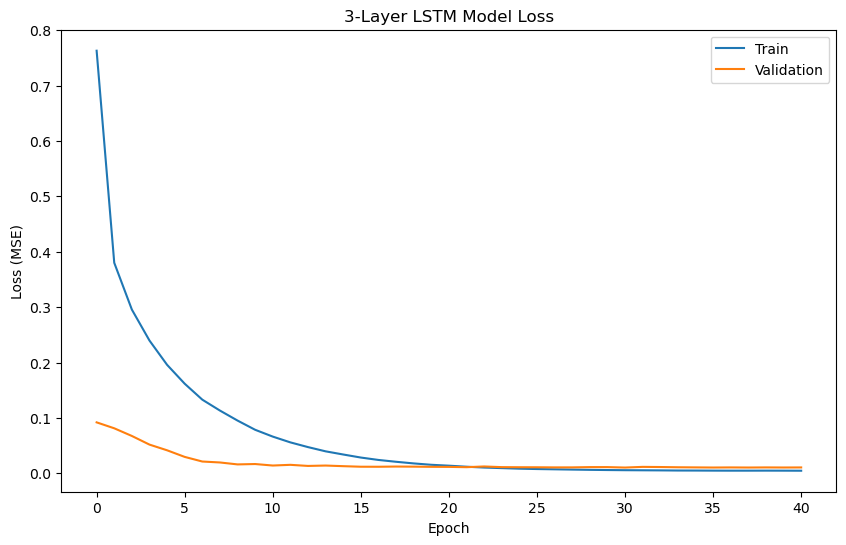

In [9]:
# Build 3-Layer LSTM model
model = Sequential([
    # First LSTM layer
    LSTM(128, return_sequences=True,
         input_shape=(time_steps, n_moneyness * n_expiry)),
    BatchNormalization(),
    Dropout(0.3),

    # Second LSTM layer
    LSTM(96, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    # Third and final LSTM layer
    LSTM(64),
    BatchNormalization(),
    Dropout(0.3),

    # Output layer
    Dense(n_moneyness * n_expiry)
])

# Compile model
model.compile(optimizer='adam', loss='mse')
model.summary()

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Set up callbacks
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint('best_medium_lstm.h5', save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=0.0001)
]

# Train model
medium_history = model.fit(
    X_train_reshaped, y_train_reshaped,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_reshaped, y_val_reshaped),
    callbacks=callbacks,
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(medium_history.history['loss'])
plt.plot(medium_history.history['val_loss'])
plt.title('3-Layer LSTM Model Loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import time

In [ ]:
def generate_trading_signals(actual_surfaces, predicted_surfaces, dates,
                            moneyness_levels, expiry_buckets):

    signals = {}

    atm_idx = np.abs(np.array(moneyness_levels) - 1.0).argmin()

    short_exp_idx = np.abs(np.array(expiry_buckets) - 30).argmin()

    for i, date in enumerate(dates[:-1]):
        next_date = dates[i+1]
        if i >= len(actual_surfaces) or i >= len(predicted_surfaces):
            continue

        actual = actual_surfaces[i]
        predicted = predicted_surfaces[i]

        actual_vol = actual[atm_idx, short_exp_idx]
        predicted_vol = predicted[atm_idx, short_exp_idx]

        vol_signal = predicted_vol - actual_vol

        signals[next_date] = vol_signal

    return signals

def determine_trades(signals, threshold=0.01):

    trades = {}

    for date, signal in signals.items():
        if signal > threshold:
            trades[date] = {
                'direction': 'LONG_VOL',
                'instrument': 'ATM_STRADDLE',
                'signal': signal
            }
        elif signal < -threshold:
            trades[date] = {
                'direction': 'SHORT_VOL',
                'instrument': 'ATM_STRADDLE',
                'signal': signal
            }
        else:
            trades[date] = {
                'direction': 'NO_TRADE',
                'instrument': None,
                'signal': signal
            }

    return trades

def apply_risk_management(trades, capital=100000, max_risk_per_trade=0.02):

    risk_managed_trades = {}

    for date, trade in trades.items():
        direction = trade['direction']
        signal = abs(trade['signal'])

        risk_fraction = min(signal * 2, max_risk_per_trade)
        position_size = capital * risk_fraction

        risk_managed_trades[date] = trade.copy()

        if direction != 'NO_TRADE':
            risk_managed_trades[date]['position_size'] = position_size
            risk_managed_trades[date]['risk_fraction'] = risk_fraction
        else:
            risk_managed_trades[date]['position_size'] = 0
            risk_managed_trades[date]['risk_fraction'] = 0

    return risk_managed_trades

def calculate_option_price(volatility, underlying_price, days_to_expiry,
                           is_call=True, moneyness=1.0):

    strike = underlying_price * moneyness
    time_in_years = max(days_to_expiry / 365, 0.01)
    vol = max(min(volatility, 2.0), 0.01)

    option_price = 0.4 * underlying_price * vol * np.sqrt(time_in_years)

    if is_call and moneyness < 1.0:  # ITM call
        option_price += (1.0 - moneyness) * underlying_price
    elif not is_call and moneyness > 1.0:  # ITM put
        option_price += (moneyness - 1.0) * underlying_price

    return max(option_price, 0.01)

def backtest_strategy(risk_managed_trades, actual_surfaces, dates,
                     moneyness_levels, expiry_buckets, underlying_prices):

    def _norm(d): 
        return pd.to_datetime(d).tz_localize(None).normalize()
    
    dates_norm = pd.DatetimeIndex([_norm(d) for d in dates])
    
    if isinstance(underlying_prices, dict):
        price_series = pd.Series(underlying_prices)
    elif isinstance(underlying_prices, pd.Series):
        price_series = underlying_prices.copy()
    else:
        raise TypeError("underlying_prices must be a dict or pandas Series")

    price_series.index = pd.to_datetime(price_series.index).tz_localize(None).normalize()
    price_series = price_series.sort_index()

    # align prices to dates_norm (no KeyErrors, no missing days)
    prices_aligned = price_series.reindex(dates_norm, method='pad')
    if prices_aligned.isna().any():
        prices_aligned = prices_aligned.fillna(method='bfill')
    if prices_aligned.isna().any():
        missing = dates_norm[prices_aligned.isna()]
        raise ValueError(f"Unable to align prices for these dates after pad/bfill: {list(missing)}")

    # if trades is a dict keyed by dates, normalize keys
    if isinstance(risk_managed_trades, dict):
        risk_managed_trades = { _norm(k): v for k, v in risk_managed_trades.items() }



    capital = 100000
    initial_capital = capital
    daily_returns = []
    equity_curve = [capital]
    positions = []
    trades_log = []

    atm_idx = np.abs(np.array(moneyness_levels) - 1.0).argmin()
    exp_30_idx = np.abs(np.array(expiry_buckets) - 30).argmin()

    open_positions = []


    for i in range(1, len(dates_norm)):
        
        
        current_date = dates_norm[i]
        prev_date    = dates_norm[i-1]
        current_price = float(prices_aligned.iloc[i])
        prev_price    = float(prices_aligned.iloc[i-1])

    
        current_vol = actual_surfaces[i][atm_idx, exp_30_idx]

        # Calculate P&L for existing positions
        day_pnl = 0
        closed_positions = []

        for j, position in enumerate(open_positions):
            entry_date, direction, entry_vol, position_size = position
            days_held = (dates.index(current_date) - dates.index(entry_date))

            # Hold positions for 5 days then close
            if days_held >= 5:
                # Calculate P&L for the position
                if direction == 'LONG_VOL':
                    vol_change = current_vol - entry_vol
                    pnl_pct = vol_change / entry_vol
                    position_pnl = position_size * pnl_pct
                else:  # 'SHORT_VOL'
                    # For short straddle, profit when vol decreases
                    vol_change = entry_vol - current_vol
                    pnl_pct = vol_change / entry_vol
                    position_pnl = position_size * pnl_pct

                day_pnl += position_pnl
                closed_positions.append(j)

                # Log the trade
                trades_log.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'direction': direction,
                    'position_size': position_size,
                    'entry_vol': entry_vol,
                    'exit_vol': current_vol,
                    'pnl': position_pnl,
                    'pnl_pct': pnl_pct * 100
                })

        for j in sorted(closed_positions, reverse=True):
            open_positions.pop(j)

        if current_date in risk_managed_trades:
            trade = risk_managed_trades[current_date]

            if trade['direction'] != 'NO_TRADE':
                position_size = trade['position_size']
                open_positions.append([
                    current_date,
                    trade['direction'],
                    current_vol,
                    position_size
                ])

        capital += day_pnl

        daily_return = day_pnl / equity_curve[-1] if equity_curve[-1] > 0 else 0
        daily_returns.append(daily_return)

        equity_curve.append(capital)

        positions.append(len(open_positions))

    total_return = (capital / initial_capital - 1) * 100

    num_years = len(dates) / 252
    annualized_return = ((capital / initial_capital) ** (1/num_years) - 1) * 100

    daily_returns_arr = np.array(daily_returns)
    annualized_vol = np.std(daily_returns_arr) * np.sqrt(252) * 100

    sharpe_ratio = annualized_return / annualized_vol if annualized_vol > 0 else 0

    running_max = np.maximum.accumulate(equity_curve)
    drawdowns = (running_max - equity_curve) / running_max * 100
    max_drawdown = np.max(drawdowns)

    winning_trades = sum(1 for trade in trades_log if trade['pnl'] > 0)
    win_rate = winning_trades / len(trades_log) if trades_log else 0

    results = {
        'equity_curve': equity_curve,
        'daily_returns': daily_returns,
        'trades': trades_log,
        'positions': positions,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_vol,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'num_trades': len(trades_log)
    }

    return results

In [12]:
def options_trading_strategy(model, data, lookback=20, test_size=0.2, model_name="LSTM"):

    print(f"Implementing Options Trading Strategy for {model_name}")
    print("--------------------------------------")

    print("Creating volatility surfaces...")

    unique_dates = sorted(data['date'].unique())
    moneyness_levels = sorted(data['moneyness_bucket'].unique())
    expiry_buckets = sorted(data['expiry_bucket'].unique())

    calls = data[data['cp_flag'] == 'C'].copy()

    underlying_prices = {}
    for date, group in data.groupby('date'):
        underlying_prices[date] = group['underlying_price'].iloc[0]

    # Create volatility surfaces
    vol_surfaces = {}
    for date in unique_dates:
        day_data = calls[calls['date'] == date]


        surface = np.zeros((len(moneyness_levels), len(expiry_buckets)))
        surface.fill(np.nan)

        for i, m in enumerate(moneyness_levels):
            for j, e in enumerate(expiry_buckets):
                subset = day_data[(day_data['moneyness_bucket'] == m) &
                                 (day_data['expiry_bucket'] == e)]
                if not subset.empty:
                    surface[i, j] = subset['impl_volatility'].mean()


        for j in range(surface.shape[1]):
            col = surface[:, j]
            mask = ~np.isnan(col)
            if np.sum(mask) > 1:
                indices = np.arange(surface.shape[0])
                interp_func = interpolate.interp1d(
                    indices[mask], col[mask],
                    bounds_error=False, fill_value="extrapolate"
                )
                surface[:, j] = interp_func(indices)

        for i in range(surface.shape[0]):
            row = surface[i, :]
            mask = ~np.isnan(row)
            if np.sum(mask) > 1:
                indices = np.arange(surface.shape[1])
                interp_func = interpolate.interp1d(
                    indices[mask], row[mask],
                    bounds_error=False, fill_value="extrapolate"
                )
                surface[i, :] = interp_func(indices)

        mean_val = np.nanmean(surface)
        surface[np.isnan(surface)] = mean_val

        vol_surfaces[date] = surface

    print("Creating LSTM input sequences...")
    X, y = [], []
    dates = sorted(list(vol_surfaces.keys()))

    for i in range(lookback, len(dates)):
        # Input sequence
        seq = []
        for j in range(i - lookback, i):
            seq.append(vol_surfaces[dates[j]])

        target = vol_surfaces[dates[i]]

        X.append(np.array(seq))
        y.append(target)

    X = np.array(X)
    y = np.array(y)

    train_size = int(len(X) * (1 - test_size))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    sequence_dates = dates[lookback:]
    train_dates = sequence_dates[:train_size]
    test_dates = sequence_dates[train_size:]

    n_samples, time_steps, n_moneyness, n_expiry = X_test.shape
    X_test_reshaped = X_test.reshape(n_samples, time_steps, n_moneyness * n_expiry)

    print("Generating volatility surface predictions...")
    start_time = time.time()
    y_pred = model.predict(X_test_reshaped)
    prediction_time = time.time() - start_time
    print(f"Prediction completed in {prediction_time:.2f} seconds")

    y_pred_surfaces = y_pred.reshape(n_samples, n_moneyness, n_expiry)

    print("Generating trading signals...")
    signals = generate_trading_signals(y_test, y_pred_surfaces, test_dates,
                                      moneyness_levels, expiry_buckets)

    print("Determining option trades...")
    trades = determine_trades(signals)

    print("Applying risk management...")
    risk_managed_trades = apply_risk_management(trades)

    print("Running backtest...")
    backtest_results = backtest_strategy(risk_managed_trades, y_test, test_dates,
                                        moneyness_levels, expiry_buckets,
                                        underlying_prices)

    print("Visualizing results...")

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 1, 1)
    plt.plot(backtest_results['equity_curve'])
    plt.title(f'Strategy Equity Curve - {model_name}')
    plt.xlabel('Trading Days')
    plt.ylabel('Portfolio Value ($)')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.bar(range(len(backtest_results['positions'])), backtest_results['positions'])
    plt.title('Number of Open Positions')
    plt.xlabel('Trading Days')
    plt.ylabel('Positions')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'{model_name}_equity_curve.png')
    plt.show()

    print(f"\nStrategy Performance Summary for {model_name}:")
    print(f"Total Return: {backtest_results['total_return']:.2f}%")
    print(f"Annualized Return: {backtest_results['annualized_return']:.2f}%")
    print(f"Annualized Volatility: {backtest_results['annualized_volatility']:.2f}%")
    print(f"Sharpe Ratio: {backtest_results['sharpe_ratio']:.2f}")
    print(f"Maximum Drawdown: {backtest_results['max_drawdown']:.2f}%")
    print(f"Win Rate: {backtest_results['win_rate']*100:.2f}%")
    print(f"Number of Trades: {backtest_results['num_trades']}")

    backtest_results['model_name'] = model_name
    backtest_results['prediction_time'] = prediction_time
    backtest_results['X_test'] = X_test
    backtest_results['y_test'] = y_test
    backtest_results['y_pred'] = y_pred
    backtest_results['test_dates'] = test_dates
    backtest_results['moneyness_levels'] = moneyness_levels
    backtest_results['expiry_buckets'] = expiry_buckets

    return backtest_results


Implementing Options Trading Strategy for 3-Layer LSTM
--------------------------------------
Creating volatility surfaces...
Creating LSTM input sequences...
Generating volatility surface predictions...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Prediction completed in 0.78 seconds
Generating trading signals...
Determining option trades...
Applying risk management...
Running backtest...
Visualizing results...


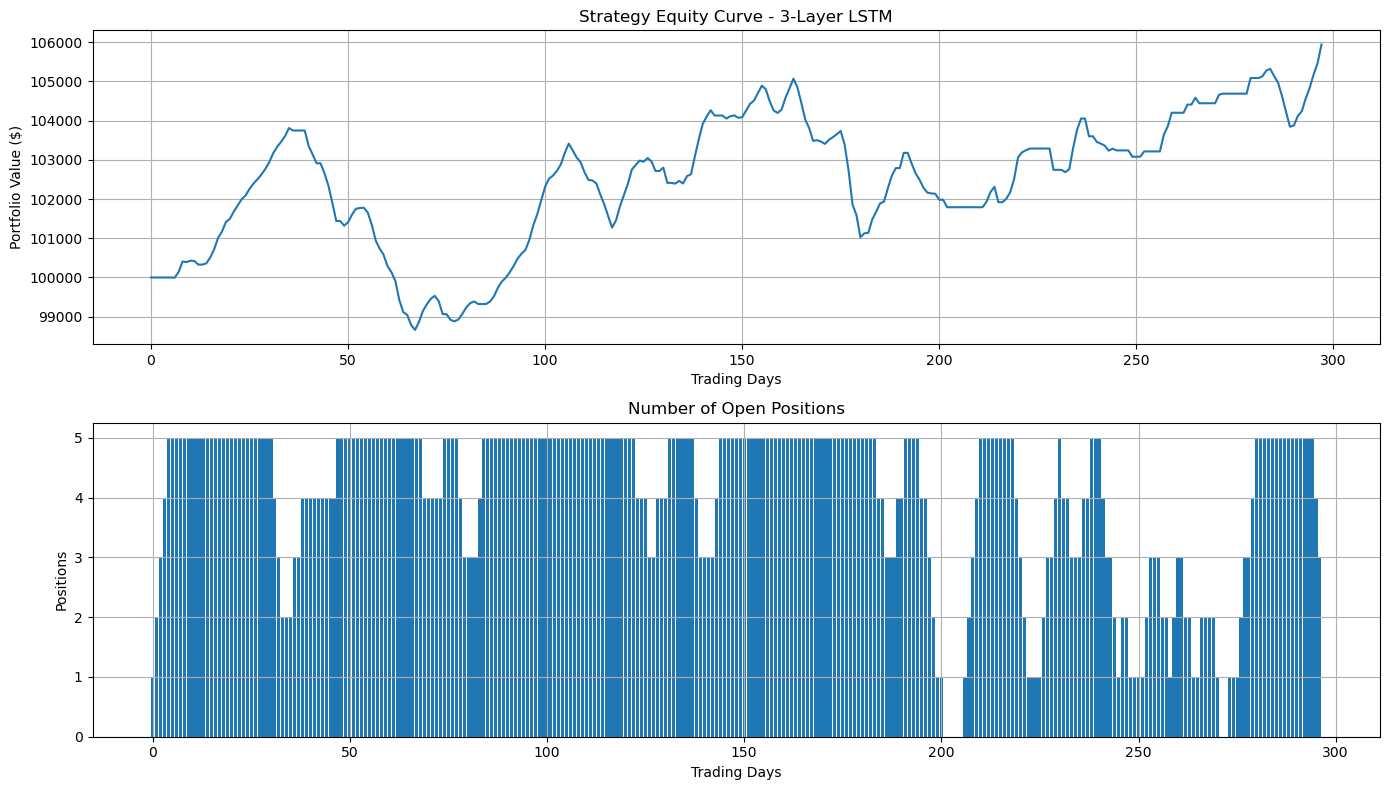


Strategy Performance Summary for 3-Layer LSTM:
Total Return: 5.94%
Annualized Return: 5.00%
Annualized Volatility: 3.26%
Sharpe Ratio: 1.54
Maximum Drawdown: 4.96%
Win Rate: 60.17%
Number of Trades: 236


In [14]:
backtest_results_3layer = options_trading_strategy(model, data, lookback=20, test_size=0.2, model_name="3-Layer LSTM")
# Results
#backtest_results_list = [backtest_results_3layer]

